# 02 — Exploratory Data Analysis (EDA)
**Project:** Predictive Analytics and AI-Driven Nutrition Solution for Early Detection and Management of Type 2 Diabetes

**Notebook:** 2 of 5

**Purpose:** Explore the cleaned dataset visually and statistically to uncover patterns, trends, and relationships between features and the target variable `glucose_spike`.

**Input:** `data/processed/glucose_spike_cleaned.csv`

**Next notebook:** `03_feature_engineering.ipynb`

---

## 0. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"]   = 120
plt.rcParams["savefig.bbox"] = "tight"

SPIKE_COLORS = {0: "#4CAF50", 1: "#E53935"}
ACCENT       = "#2196F3"
RANDOM_STATE = 42

print("Libraries loaded.")

---
## 1. Load Cleaned Dataset

In [ ]:
df = pd.read_csv("data/processed/glucose_spike_cleaned.csv")
print(f"Loaded — {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

---
# 4. Exploratory Data Analysis

## 4.1 Univariate Analysis - Distributions

In [15]:
numerical_features = [
    "pre_meal_glucose", "post_meal_glucose", "bmi",
    "carb_intake", "protein_intake", "fat_intake",
    "fiber_intake", "sugar_intake",
]

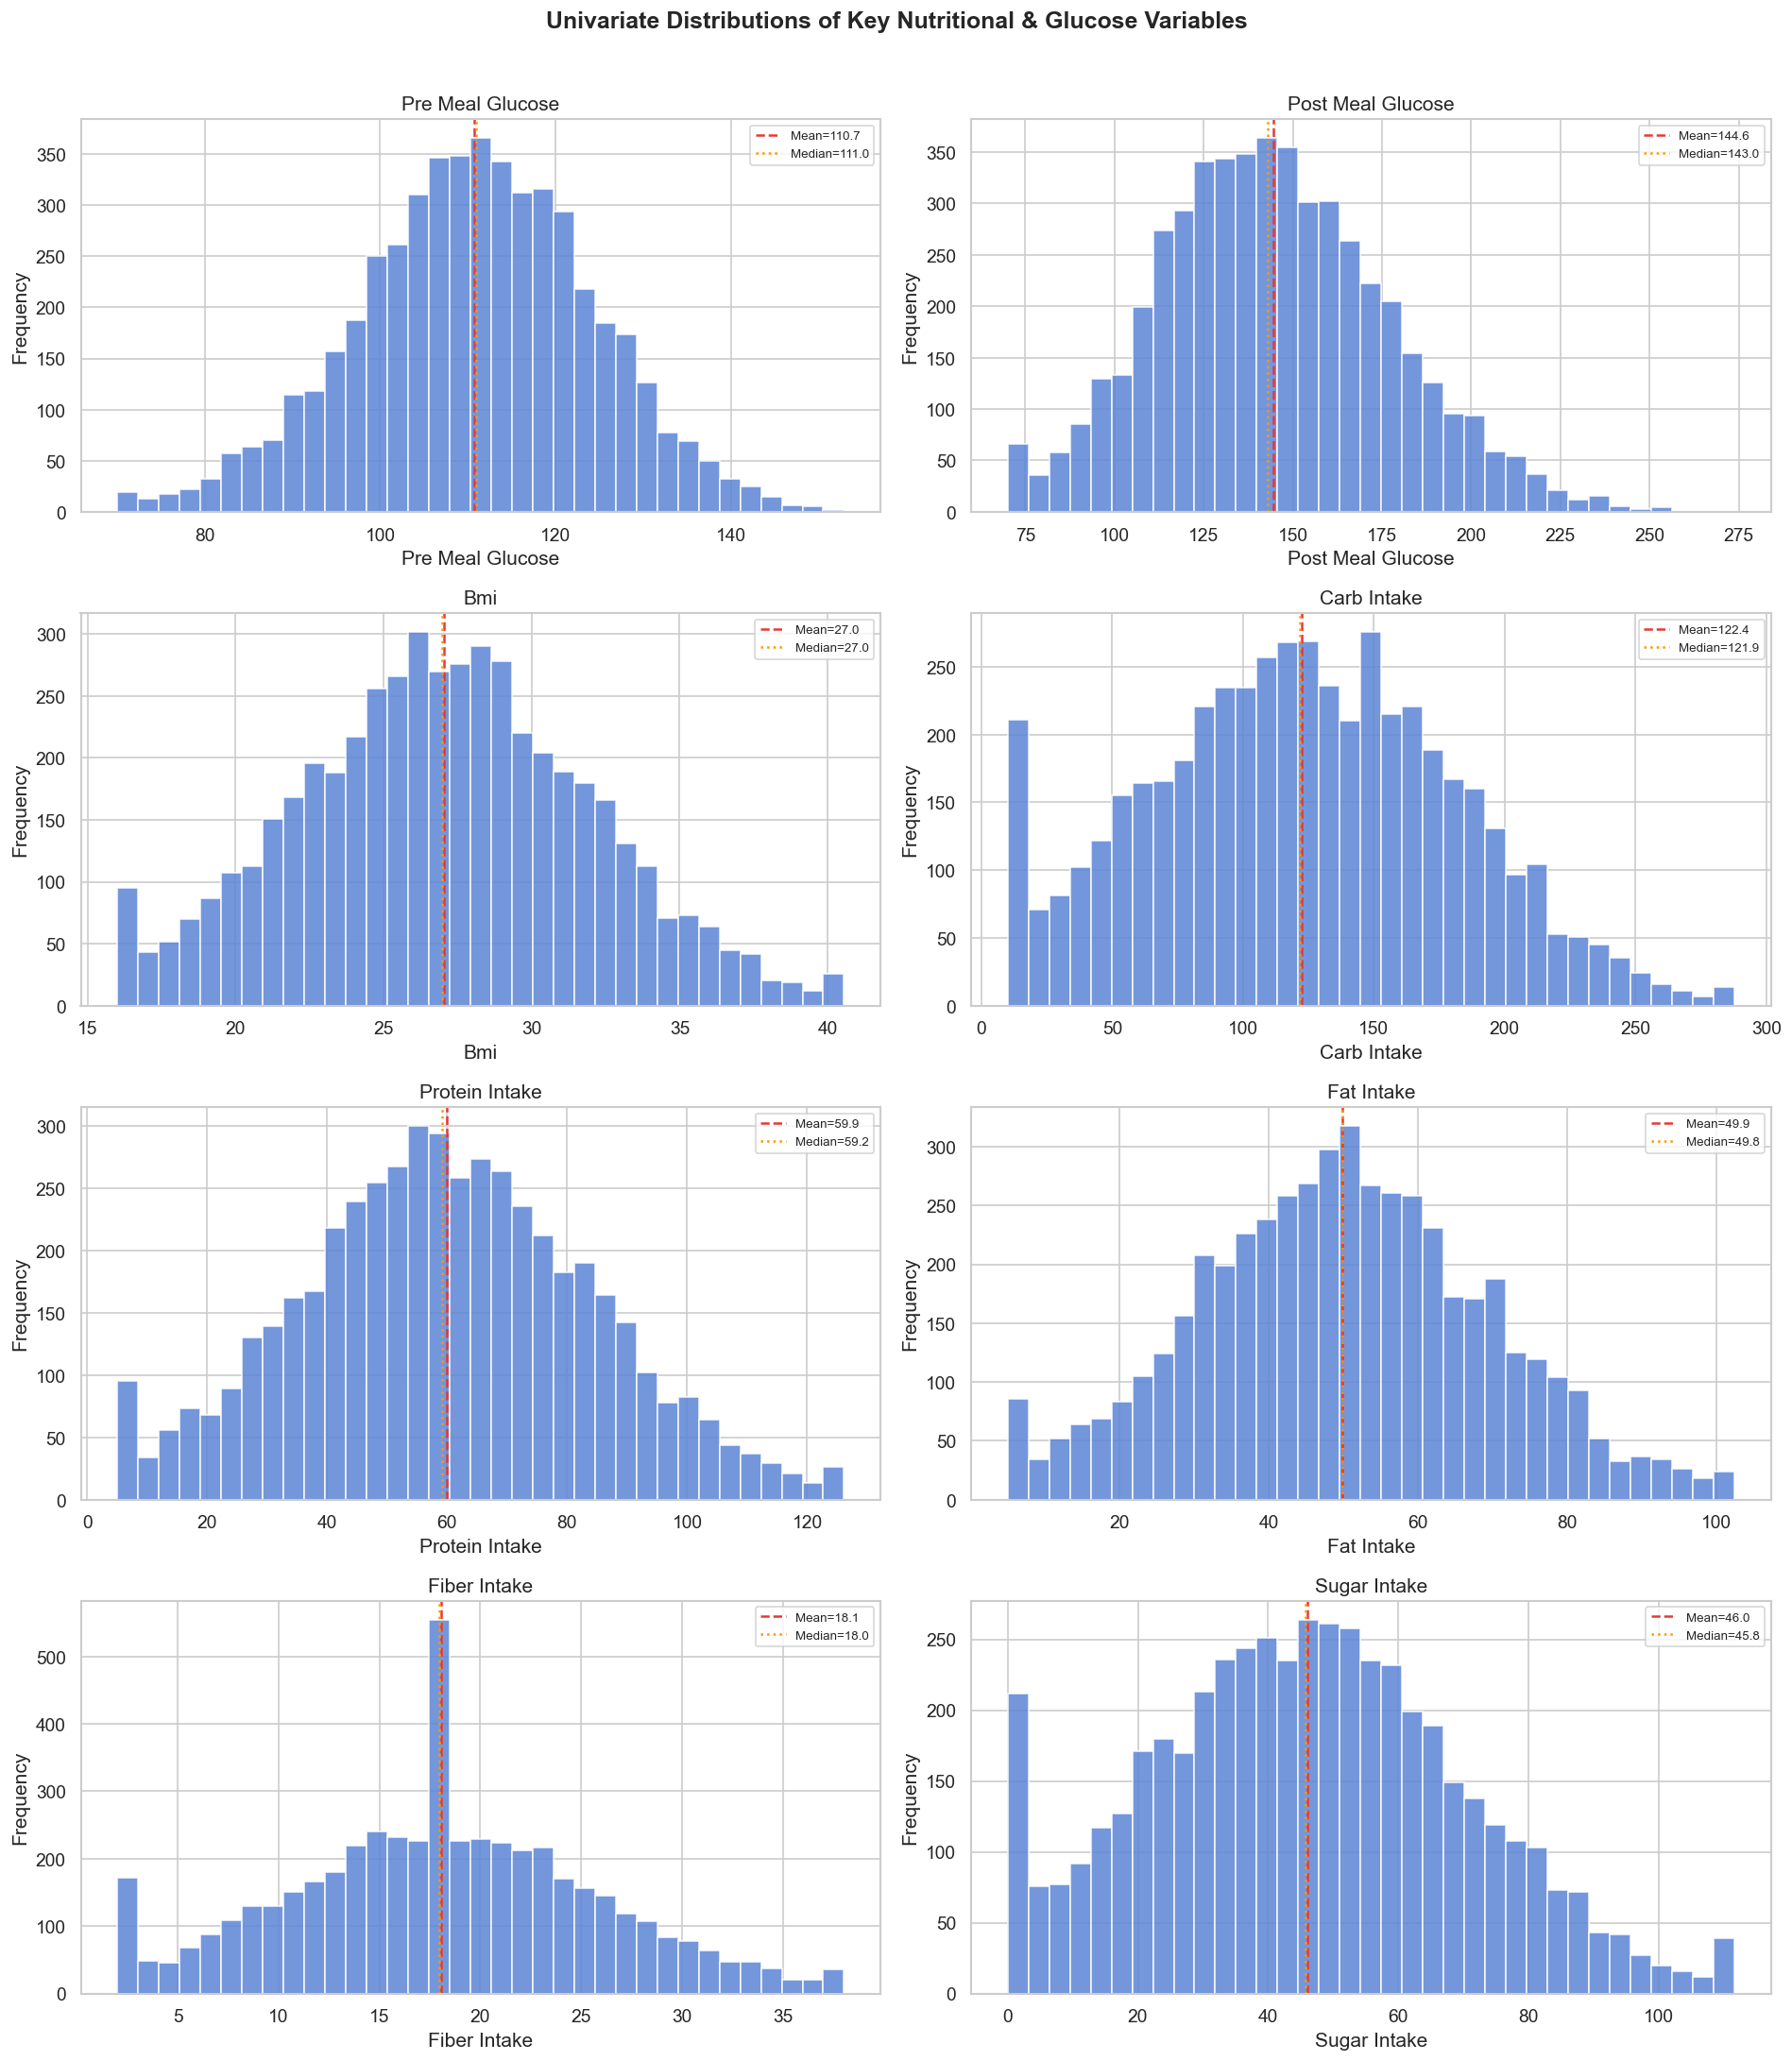

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle("Univariate Distributions of Key Nutritional & Glucose Variables",
             fontsize=15, fontweight="bold", y=1.01)

for ax, col in zip(axes.flat, numerical_features):
    data = df[col].dropna()
    ax.hist(data, bins=35, color="#5C85D6", edgecolor="white", alpha=0.85)

    # adding mean and median lines gives a quick sense of skewness
    ax.axvline(data.mean(),   color="#E53935", linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.1f}")
    ax.axvline(data.median(), color="#FF9800", linestyle=":",  linewidth=1.5,
               label=f"Median={data.median():.1f}")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4.2 Target Variable Distribution

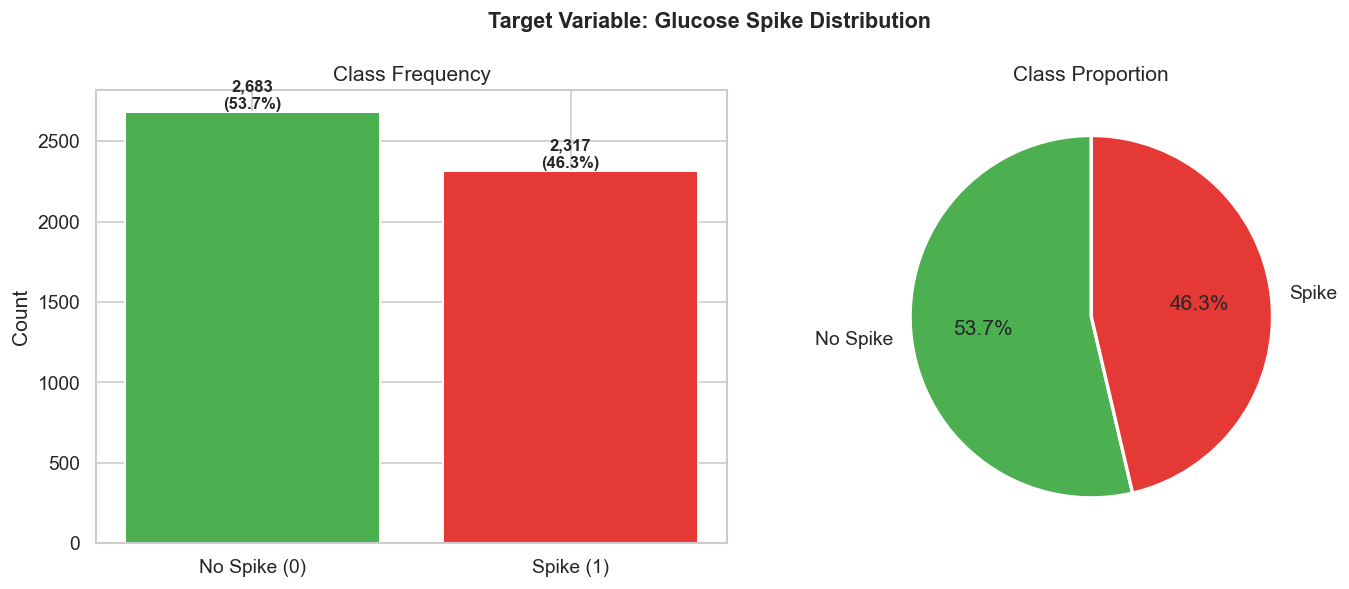

Spike rate: 46.3%  (2,317 of 5,000 meals)


In [17]:
spike_counts = df["glucose_spike"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable: Glucose Spike Distribution", fontsize=13, fontweight="bold")

# bar chart for absolute counts
bars = axes[0].bar(["No Spike (0)", "Spike (1)"], spike_counts.values,
                   color=["#4CAF50", "#E53935"], edgecolor="white", linewidth=1.2)
axes[0].set_title("Class Frequency")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, spike_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", fontsize=10, fontweight="bold")

# pie chart for proportions
axes[1].pie(spike_counts.values, labels=["No Spike", "Spike"],
            colors=["#4CAF50", "#E53935"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.show()

print(f"Spike rate: {spike_counts[1]/len(df)*100:.1f}%  ({spike_counts[1]:,} of {len(df):,} meals)")

## 4.3 Correlation Heatmap

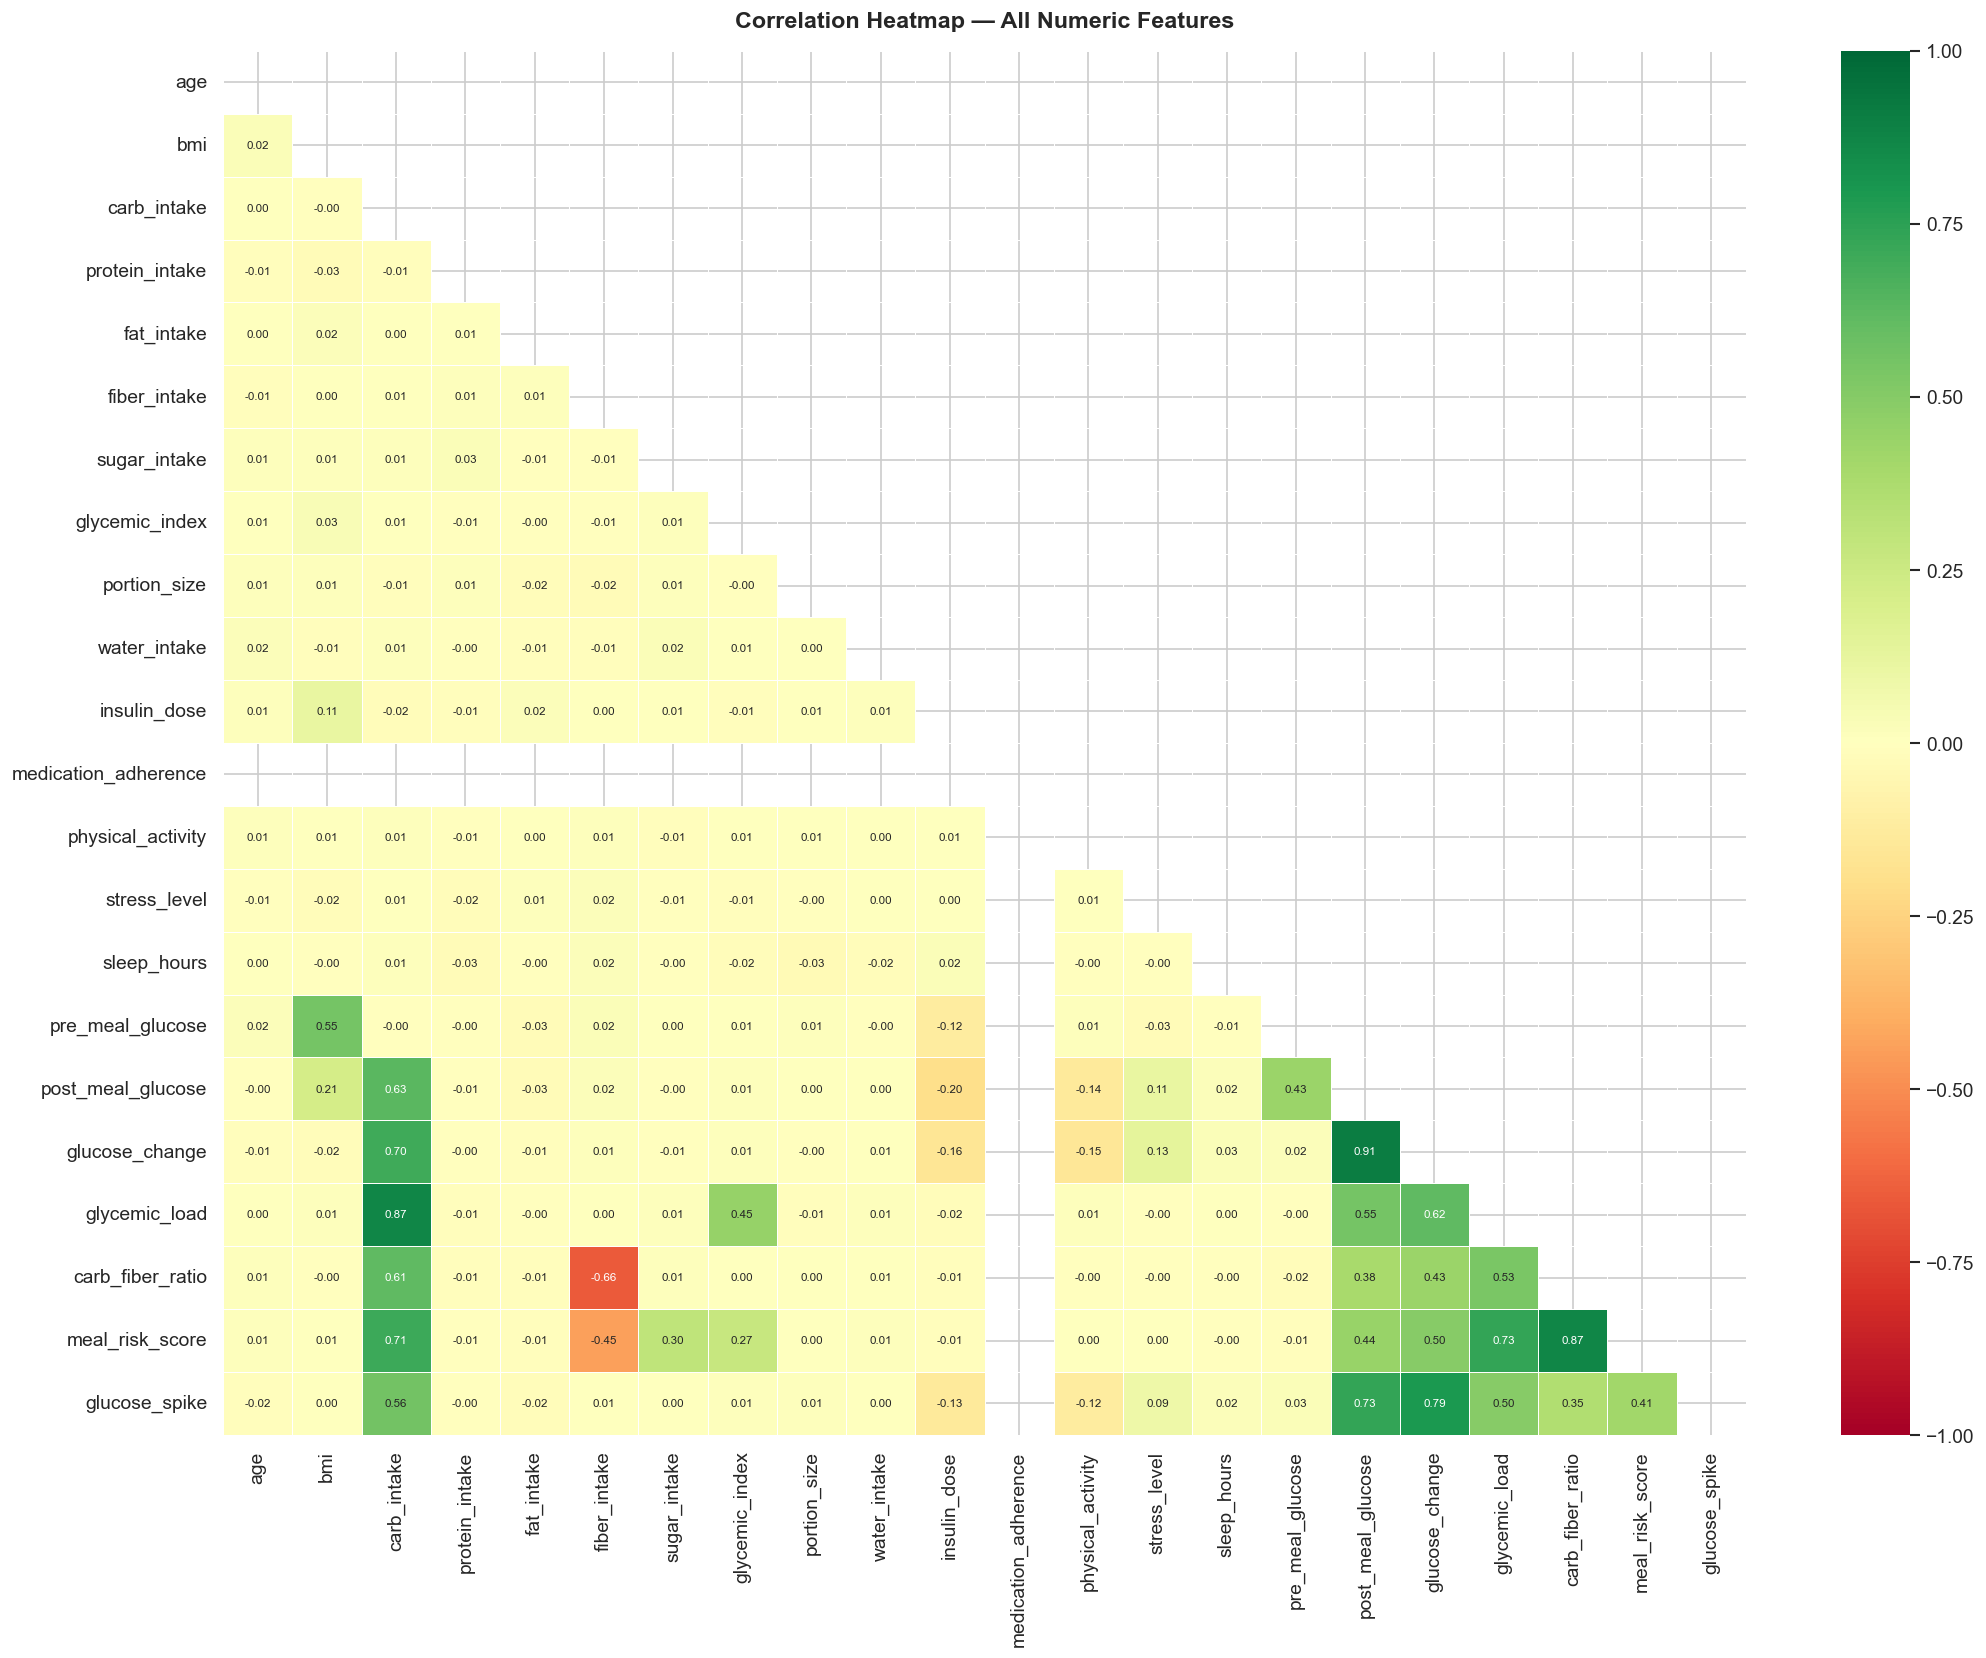

Top positive correlations with glucose_spike:
stress_level            0.086220
carb_fiber_ratio        0.354461
meal_risk_score         0.406521
glycemic_load           0.498410
carb_intake             0.561516
post_meal_glucose       0.726588
glucose_change          0.794283
medication_adherence         NaN

Top negative correlations with glucose_spike:
insulin_dose        -0.132956
physical_activity   -0.117208
fat_intake          -0.017419
age                 -0.015375
protein_intake      -0.002497


In [18]:
numeric_df  = df.select_dtypes(include=np.number).drop(columns=["patient_id"])
corr_matrix = numeric_df.corr()

# masking the upper triangle keeps it clean and avoids reading the same number twice
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.4,
            annot_kws={"size": 7}, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap — All Numeric Features",
             fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

# pull out the features most correlated with our target
spike_corr = corr_matrix["glucose_spike"].drop("glucose_spike").sort_values()
print("Top positive correlations with glucose_spike:")
print(spike_corr.tail(8).to_string())
print("\nTop negative correlations with glucose_spike:")
print(spike_corr.head(5).to_string())

## 4.4 Scatter Plot - Carb Intake vs Glucose Change

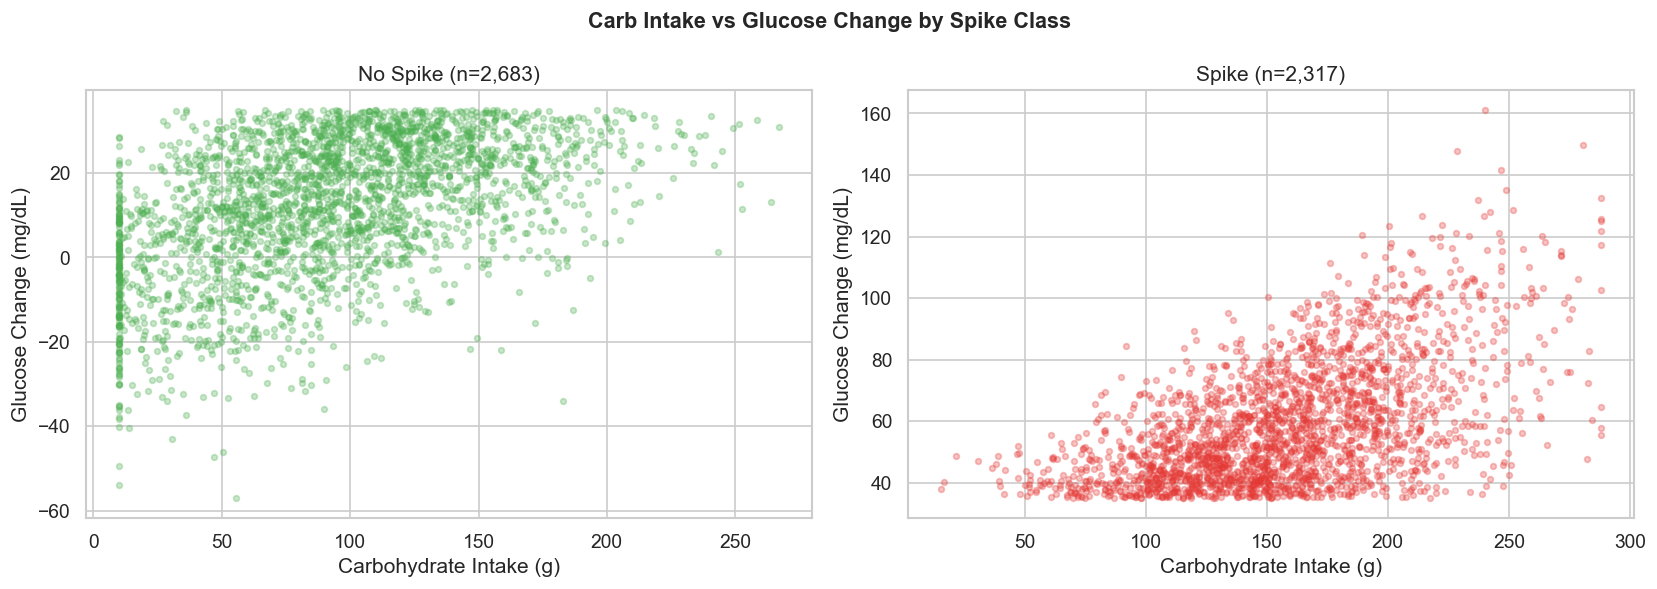

In [19]:
# splitting by spike class makes it easier to see if there is a visible separation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Carb Intake vs Glucose Change by Spike Class", fontsize=13, fontweight="bold")

SPIKE_COLORS = {0: "#4CAF50", 1: "#E53935"}
for spike_val, ax in zip([0, 1], axes):
    subset = df[df["glucose_spike"] == spike_val]
    ax.scatter(subset["carb_intake"], subset["glucose_change"],
               alpha=0.3, s=12, color=SPIKE_COLORS[spike_val])
    ax.set_xlabel("Carbohydrate Intake (g)")
    ax.set_ylabel("Glucose Change (mg/dL)")
    label = "No Spike" if spike_val == 0 else "Spike"
    ax.set_title(f"{label} (n={len(subset):,})")

plt.tight_layout()
plt.show()

## 4.5 Group-Based Spike Rate Analysis

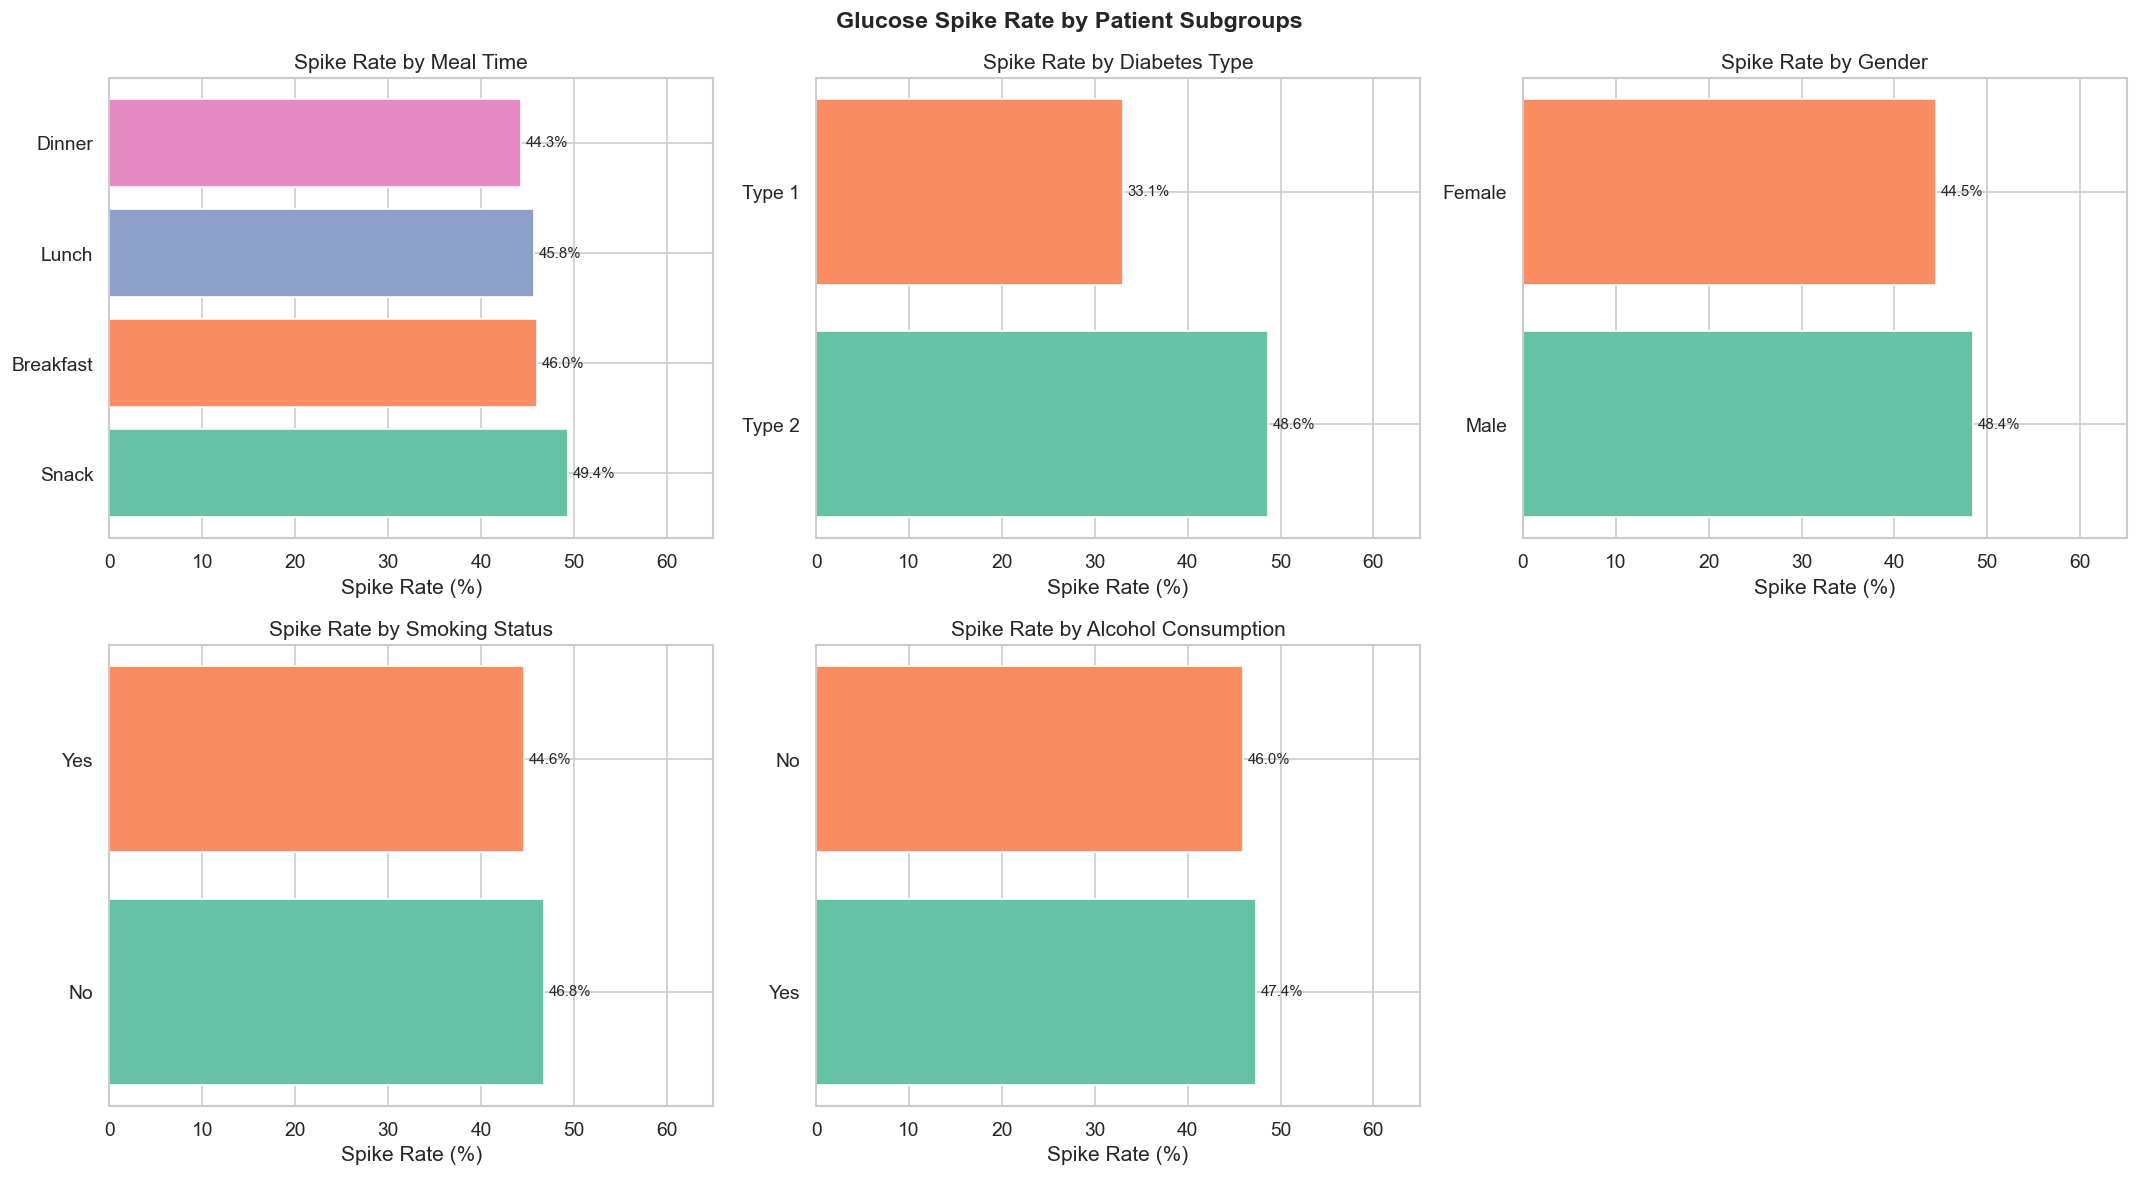

In [20]:
# looking at spike rates across patient subgroups helps identify who is most at risk
group_vars = {
    "Meal Time"          : "meal_time",
    "Diabetes Type"      : "diabetes_type",
    "Gender"             : "gender",
    "Smoking Status"     : "smoking_status",
    "Alcohol Consumption": "alcohol_consumption",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Glucose Spike Rate by Patient Subgroups", fontsize=14, fontweight="bold")

for (label, col), ax in zip(group_vars.items(), axes.flat):
    rates = (df.groupby(col)["glucose_spike"]
               .mean().mul(100)
               .sort_values(ascending=False)
               .reset_index())
    rates.columns = [col, "spike_rate"]
    bars = ax.barh(rates[col], rates["spike_rate"],
                   color=sns.color_palette("Set2", len(rates)), edgecolor="white")
    ax.set_xlabel("Spike Rate (%)")
    ax.set_title(f"Spike Rate by {label}")
    ax.set_xlim(0, 65)
    for bar, val in zip(bars, rates["spike_rate"]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=9)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()